# Foodwaste Prediction

## Librerías 

In [24]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid

%matplotlib inline

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

IN_PATH = 'roca_nivaria_datos.xlsx'
TARGET = 'Desperdicio (kg)'


## EDA

In [ ]:
# Cargamos el dataset
df = pd.read_excel(IN_PATH, sheet_name='Adrián Hoteles')

# Añadimos una columna con la fecha en formato datetime
df['fecha'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Mostramos información básica del dataset
print(f"Tamaño dataset: {df.shape}")
print(f"Rango fechas: Desde {df['fecha'].min().date()} hasta {df['fecha'].max().date()}")
df.head()

Tamaño dataset: (15371, 20)
Rango fechas: Desde 2025-05-05 hasta 2026-07-01


,Date,turno,plato,% KG,% Reducción,% Reducción Total,_Tiene Datos,CO2,Comensales,Desperdicio (kg),Desviación %,KG Base,KG Evitados,KG Evitados Totales,kg/Comensal,KG Reales,Registros Procesados,Cobertura Comensales %,Cobertura Pesaje %,fecha
0,05/05/2025,DESAYUNO,Cereales,0.000024,0.774194,0.774194,1,1.75,616.0,0.70,16.907819,3.10,2.40,2.40,0.001136,0.70,1,1.0,1,2025-05-05
1,05/05/2025,DESAYUNO,Creps,0.000038,0.827316,0.827316,1,2.75,616.0,1.10,11.620748,6.37,5.27,5.27,0.001786,1.10,1,1.0,1,2025-05-05
2,05/05/2025,DESAYUNO,Croissant,0.000003,0.750000,0.750000,1,0.25,616.0,0.10,5.692821,0.40,0.30,0.30,0.000162,0.10,1,1.0,1,2025-05-05
3,05/05/2025,DESAYUNO,Dulces,0.000014,0.871166,0.871166,1,1.05,616.0,0.42,11.630295,3.26,2.84,2.84,0.000682,0.42,1,1.0,1,2025-05-05
4,05/05/2025,DESAYUNO,Embutidos,0.000024,0.916468,0.916468,1,1.75,616.0,0.70,1.967767,8.38,7.68,7.68,0.001136,0.70,1,1.0,1,2025-05-05


### Data Leakage

Varias columnas del export se calculan a partir del propio Desperdicio (kg) y no pueden usarse como feature ya que no estarán disponibles antes de que ocurra el desperdicio:

| Columna | Relación con el target |
|---|---|
| CO2 | = Desperdicio × 2.5 |
| KG Reales, % KG | correlación 1.0 |
| kg/Comensal | = Desperdicio / Comensales |
| KG Evitados | = max(0, KG Base − Desperdicio) |
| % Reducción, % Reducción Total | = KG Evitados / KG Base |
| Desviación % | derivada post-hoc del resultado del día |

In [28]:
LEAKAGE_COLS = [
    '% KG', 'CO2', 'KG Reales', 'kg/Comensal',
    'KG Evitados', 'KG Evitados Totales',
    '% Reducción', '% Reducción Total', 'Desviación %',
]

NO_VARIANCE_COLS = ['_Tiene Datos', 'Cobertura Pesaje %', 'Cobertura Comensales %']

corr = df[LEAKAGE_COLS + [TARGET]].corr()[TARGET].sort_values(ascending=False)
corr

CO2                    1.000000
KG Reales              1.000000
Desperdicio (kg)       1.000000
% KG                   1.000000
kg/Comensal            0.851421
KG Evitados            0.476616
KG Evitados Totales    0.476616
Desviación %           0.137447
% Reducción           -0.091524
% Reducción Total     -0.091524
Name: Desperdicio (kg), dtype: float64

### Visualización de datos

In [29]:
# Estadísticas principales
y = df[TARGET]
print(y.describe(percentiles=[.5, .75, .9, .95, .99]))
print(f"\nSkew: {y.skew():.2f} | Kurtosis: {y.kurt():.2f}")
print(f"Skew tras log1p: {np.log1p(y).skew():.2f}")

count    15371.000000
mean         1.902544
std          2.675781
min          0.020000
50%          1.180000
75%          2.080000
90%          4.090000
95%          6.170000
99%         11.440000
max        103.400000
Name: Desperdicio (kg), dtype: float64

Skew: 10.42 | Kurtosis: 278.00
Skew tras log1p: 1.15


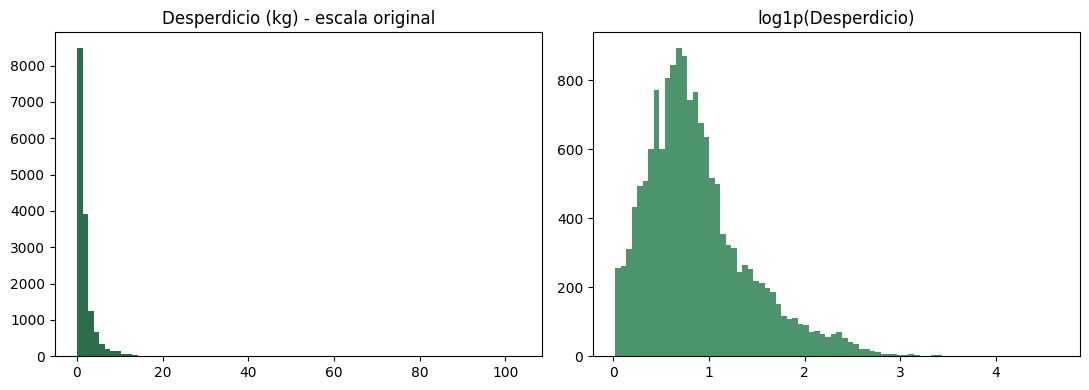

In [30]:
# Distribución de target
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y, bins=80, color='#2C6E49')
axes[0].set_title('Desperdicio (kg) - escala original')
axes[1].hist(np.log1p(y), bins=80, color='#4C956C')
axes[1].set_title('log1p(Desperdicio)')
fig.tight_layout()
plt.show()

### Desperdicio por turno

In [ ]:
print(df.groupby('turno')[TARGET].describe())

fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column=TARGET, by='turno', ax=ax, showfliers=False)
ax.set_title('Desperdicio por turno (sin outliers)')
plt.suptitle('')
fig.tight_layout()
plt.show()

### Estacionalidad

In [ ]:
d = df.copy()
d['mes'] = d['fecha'].dt.month
d['dow'] = d['fecha'].dt.dayofweek
print(d.groupby('mes')[[TARGET, 'Comensales']].mean())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
d.groupby('mes')[TARGET].mean().plot(kind='bar', ax=axes[0], color='#B85042')
axes[0].set_title('Desperdicio medio por mes')
d.groupby('mes')['Comensales'].mean().plot(kind='bar', ax=axes[1], color='#3B6E8F')
axes[1].set_title('Comensales medio por mes')
fig.tight_layout()
plt.show()

### Desviación y medias por platos y turnos

In [ ]:
g = df.groupby(['plato', 'turno'])[TARGET].agg(['mean', 'std', 'count'])
g = g[g['count'] >= 15].sort_values('mean', ascending=False)
print(g.head(15))

cnt = df.groupby(['plato', 'turno']).size()
print(f"\nCombinaciones plato+turno con <10 registros: {(cnt < 10).sum()} de {len(cnt)}")
print(f"Combinaciones plato+turno con <30 registros: {(cnt < 30).sum()} de {len(cnt)}")

### Valores faltantes

In [ ]:
print(df.isna().sum()[df.isna().sum() > 0])

missing_dates = df[df['Comensales'].isna()][['fecha', 'turno']].drop_duplicates()
print(f"\nComensales falta en {missing_dates['fecha'].nunique()} fechas completas (servicios enteros sin registrar, no aleatorio):")
print(missing_dates.sort_values('fecha').to_string(index=False))

### Kg base estandar

In [ ]:
nun = df.groupby(['plato', 'turno'])['KG Base'].nunique()
print(f"KG Base es constante dentro de (plato,turno) en {(nun == 1).sum()} de {len(nun)} casos.")
print(f"({(nun == 0).sum()} combinaciones no tienen ningún valor -> platos nuevos sin referencia configurada aún)")
print(f"Correlación KG Base vs target: {df[['KG Base', TARGET]].corr().iloc[0, 1]:.3f}")

## Preprocesamiento

In [ ]:
def load_raw(path):
    df = pd.read_excel(path, sheet_name='Adrián Hoteles')
    df['fecha'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
    df = df.drop(columns=['Date'] + LEAKAGE_COLS + NO_VARIANCE_COLS)
    df = df.sort_values(['fecha', 'turno', 'plato']).reset_index(drop=True)
    return df

### Feature de calendario

In [ ]:
def add_calendar_features(df):
    df['anio'] = df['fecha'].dt.year
    df['mes'] = df['fecha'].dt.month
    df['dia_semana'] = df['fecha'].dt.dayofweek  # 0=lunes
    df['es_finde'] = df['dia_semana'].isin([5, 6]).astype(int)
    df['dia_mes'] = df['fecha'].dt.day
    df['semana_anio'] = df['fecha'].dt.isocalendar().week.astype(int)
    return df

### Imputación

`Comensales` falta en servicios enteros -> mediana por turno + día de semana.
`KG Base` falta en platos nuevos/raros -> mediana por turno. Ambas con flag de imputación.

In [ ]:
def impute_comensales(df):
    df['comensales_imputado'] = df['Comensales'].isna().astype(int)
    fallback = df.groupby(['turno', 'dia_semana'])['Comensales'].transform('median')
    df['Comensales'] = df['Comensales'].fillna(fallback)
    fallback_turno = df.groupby('turno')['Comensales'].transform('median')
    df['Comensales'] = df['Comensales'].fillna(fallback_turno)
    return df


def impute_kg_base(df):
    df['kg_base_imputado'] = df['KG Base'].isna().astype(int)
    fallback = df.groupby('turno')['KG Base'].transform('median')
    df['KG Base'] = df['KG Base'].fillna(fallback)
    return df

### Feature históricas casuales

In [ ]:
def add_historical_features(df):

    df = df.sort_values(["plato", "turno", "fecha"]).copy()

    grupo = df.groupby(["plato", "turno"])

    # Nº observaciones previas
    df["hist_n_obs"] = grupo.cumcount()

    # LAGS
    for lag in [1, 7, 14, 28]:
        df[f"hist_lag{lag}"] = grupo[TARGET].shift(lag)

    # MEDIA EXPANDIDA
    df["hist_media_expandida"] = (
        grupo[TARGET]
        .transform(lambda x: x.shift(1).expanding().mean())
    )

    # STD EXPANDIDA
    df["hist_std_expandida"] = (
        grupo[TARGET]
        .transform(lambda x: x.shift(1).expanding().std())
    )

    # MEDIAS MÓVILES
    for w in [3, 5, 7, 14, 28]:

        df[f"hist_media_movil_{w}"] = (
            grupo[TARGET]
            .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        )

    # STD MÓVIL
    for w in [7, 14]:

        df[f"hist_std_{w}"] = (
            grupo[TARGET]
            .transform(lambda x: x.shift(1).rolling(w, min_periods=2).std())
        )

    # TENDENCIA
    df["hist_tendencia"] = (
        df["hist_media_movil_7"]
        - df["hist_media_movil_28"]
    )

    return df

def encode_categoricals(df):
    for col in ['plato', 'turno']:
        df[col] = df[col].astype('category')
    return df

In [ ]:
import pandas as pd
import numpy as np

try:
    import holidays
except ImportError:
    raise ImportError(
        "Necesitas instalar la librería holidays. Ejecuta: pip install holidays"
    )


def add_advanced_calendar_features(df, fecha_col="fecha"):
    df = df.copy()
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    years = sorted(df[fecha_col].dt.year.unique())

    # Festivos nacionales de España
    festivos_es = holidays.Spain(years=years)

    # Festivos autonómicos de Canarias
    festivos_cn = holidays.Spain(subdiv="CN", years=years)

    festivos = set(festivos_es.keys()) | set(festivos_cn.keys())
    festivos = pd.to_datetime(list(festivos))

    df["es_festivo"] = df[fecha_col].isin(festivos).astype(int)

    # Víspera y día posterior a festivo
    festivos_previos = festivos - pd.Timedelta(days=1)
    festivos_posteriores = festivos + pd.Timedelta(days=1)

    df["vispera_festivo"] = df[fecha_col].isin(festivos_previos).astype(int)
    df["dia_post_festivo"] = df[fecha_col].isin(festivos_posteriores).astype(int)

    # Puente: lunes o viernes junto a festivo, o día laborable entre festivo y fin de semana
    df["es_lunes"] = (df[fecha_col].dt.dayofweek == 0).astype(int)
    df["es_viernes"] = (df[fecha_col].dt.dayofweek == 4).astype(int)

    df["festivo_manana"] = df[fecha_col].add(pd.Timedelta(days=1)).isin(festivos).astype(int)
    df["festivo_ayer"] = df[fecha_col].sub(pd.Timedelta(days=1)).isin(festivos).astype(int)

    df["es_puente"] = (
        (
            (df["es_lunes"] == 1) & (df["festivo_ayer"] == 1)
        )
        |
        (
            (df["es_viernes"] == 1) & (df["festivo_manana"] == 1)
        )
        |
        (
            (df["festivo_ayer"] == 1) & (df["festivo_manana"] == 1)
        )
    ).astype(int)

    # Vacaciones escolares aproximadas
    mes = df[fecha_col].dt.month
    dia = df[fecha_col].dt.day

    df["vacaciones_escolares"] = (
        (mes.isin([7, 8])) |
        ((mes == 12) & (dia >= 20)) |
        ((mes == 1) & (dia <= 7)) |
        ((mes == 4) & (dia.between(1, 15)))
    ).astype(int)

    # Temporada turística aproximada para Canarias
    conditions = [
        mes.isin([7, 8, 12]),
        mes.isin([3, 4, 5, 6, 9, 10, 11]),
        mes.isin([1, 2])
    ]

    choices = [
        "alta",
        "media",
        "baja"
    ]

    df["temporada_turistica"] = np.select(
        conditions,
        choices,
        default="media"
    )

    # Variable binaria de temporada alta
    df["temporada_alta"] = (df["temporada_turistica"] == "alta").astype(int)

    # Evento local: por defecto 0.
    # Esta variable conviene sustituirla más adelante por una tabla real de eventos.
    df["evento_local"] = 0

    # Limpieza de columnas auxiliares
    df = df.drop(
        columns=[
            "es_lunes",
            "es_viernes",
            "festivo_manana",
            "festivo_ayer"
        ],
        errors="ignore"
    )

    return df


df_p = add_advanced_calendar_features(df_p)

calendar_extra_cols = [
    "es_festivo",
    "vispera_festivo",
    "dia_post_festivo",
    "es_puente",
    "vacaciones_escolares",
    "temporada_turistica",
    "temporada_alta",
    "evento_local",
]

df_p[["fecha"] + calendar_extra_cols].head()

In [ ]:
def add_temporal_features(df, fecha_col="fecha"):
    df = df.copy()
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    # Posición dentro del mes
    df["inicio_mes"] = (df[fecha_col].dt.day <= 5).astype(int)
    df["fin_mes"] = (df[fecha_col].dt.day >= 25).astype(int)

    # Posición dentro de la semana
    df["inicio_semana"] = (df[fecha_col].dt.dayofweek <= 1).astype(int)
    df["fin_semana"] = (df[fecha_col].dt.dayofweek >= 5).astype(int)

    # Variables cíclicas para capturar patrones anuales y semanales
    df["mes_sin"] = np.sin(2 * np.pi * df[fecha_col].dt.month / 12)
    df["mes_cos"] = np.cos(2 * np.pi * df[fecha_col].dt.month / 12)

    df["dia_semana_sin"] = np.sin(2 * np.pi * df[fecha_col].dt.dayofweek / 7)
    df["dia_semana_cos"] = np.cos(2 * np.pi * df[fecha_col].dt.dayofweek / 7)

    df["dia_anio"] = df[fecha_col].dt.dayofyear
    df["dia_anio_sin"] = np.sin(2 * np.pi * df["dia_anio"] / 365)
    df["dia_anio_cos"] = np.cos(2 * np.pi * df["dia_anio"] / 365)

    # Días hasta próximo festivo y desde último festivo
    festivos = df.loc[df["es_festivo"] == 1, fecha_col].drop_duplicates().sort_values()

    if len(festivos) > 0:
        fechas = df[fecha_col]

        df["dias_desde_ultimo_festivo"] = fechas.apply(
            lambda x: (x - festivos[festivos <= x].max()).days
            if len(festivos[festivos <= x]) > 0 else np.nan
        )

        df["dias_hasta_proximo_festivo"] = fechas.apply(
            lambda x: (festivos[festivos >= x].min() - x).days
            if len(festivos[festivos >= x]) > 0 else np.nan
        )

        df["dias_desde_ultimo_festivo"] = df["dias_desde_ultimo_festivo"].fillna(999)
        df["dias_hasta_proximo_festivo"] = df["dias_hasta_proximo_festivo"].fillna(999)

    else:
        df["dias_desde_ultimo_festivo"] = 999
        df["dias_hasta_proximo_festivo"] = 999

    return df


df_p = add_temporal_features(df_p)

temporal_extra_cols = [
    "inicio_mes",
    "fin_mes",
    "inicio_semana",
    "fin_semana",
    "mes_sin",
    "mes_cos",
    "dia_semana_sin",
    "dia_semana_cos",
    "dia_anio",
    "dia_anio_sin",
    "dia_anio_cos",
    "dias_desde_ultimo_festivo",
    "dias_hasta_proximo_festivo",
]

df_p[["fecha"] + temporal_extra_cols].head()

In [ ]:
import requests
import pandas as pd
import numpy as np


# ==========================================================
# VARIABLES METEOROLÓGICAS AUTOMÁTICAS SEGÚN FECHA
# Fuente: Open-Meteo Historical Weather API
# ==========================================================

LATITUDE = 28.1227      # Ejemplo Tenerife sur
LONGITUDE = -16.7260    # Cambiar por coordenadas reales del hotel


def get_weather_features_from_open_meteo(
    df,
    fecha_col="fecha",
    latitude=LATITUDE,
    longitude=LONGITUDE,
):
    df = df.copy()
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    start_date = df[fecha_col].min().strftime("%Y-%m-%d")
    end_date = df[fecha_col].max().strftime("%Y-%m-%d")

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "wind_speed_10m_max",
        ],
        "timezone": "Europe/Madrid",
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    data = response.json()

    weather = pd.DataFrame(data["daily"])
    weather["fecha"] = pd.to_datetime(weather["time"])
    weather = weather.drop(columns=["time"])

    weather = weather.rename(
        columns={
            "temperature_2m_mean": "temperatura_media",
            "temperature_2m_max": "temperatura_max",
            "temperature_2m_min": "temperatura_min",
            "precipitation_sum": "precipitacion_mm",
            "wind_speed_10m_max": "viento_kmh",
        }
    )

    # Variables derivadas
    weather["lluvia"] = (weather["precipitacion_mm"] > 0).astype(int)
    weather["dia_lluvioso"] = (weather["precipitacion_mm"] >= 1).astype(int)
    weather["dia_caluroso"] = (weather["temperatura_max"] >= 30).astype(int)

    # Open-Meteo Archive no devuelve calima directamente.
    # La dejamos preparada como variable externa/manual o para futura integración con AEMET/Copernicus.
    weather["calima"] = 0

    df = df.merge(weather, on="fecha", how="left")

    return df


df_p = get_weather_features_from_open_meteo(df_p)

weather_cols = [
    "temperatura_media",
    "temperatura_max",
    "temperatura_min",
    "precipitacion_mm",
    "lluvia",
    "dia_lluvioso",
    "dia_caluroso",
    "viento_kmh",
    "calima",
]

df_p[["fecha"] + weather_cols].head()

In [ ]:
historical_cols = [
    "hist_n_obs",

    "hist_lag1",
    "hist_lag7",
    "hist_lag14",
    "hist_lag28",

    "hist_media_expandida",

    "hist_media_movil_3",
    "hist_media_movil_5",
    "hist_media_movil_7",
    "hist_media_movil_14",
    "hist_media_movil_28",

    "hist_std_expandida",
    "hist_std_7",
    "hist_std_14",

    "hist_tendencia"
]

## Split temporal

In [ ]:
def temporal_train_val_test_split(df, val_fraction_days=0.15, test_fraction_days=0.15):
    dates = np.sort(df["fecha"].unique())
    n_dates = len(dates)

    test_start_idx = int(n_dates * (1 - test_fraction_days))
    val_start_idx = int(n_dates * (1 - test_fraction_days - val_fraction_days))

    val_start_date = dates[val_start_idx]
    test_start_date = dates[test_start_idx]

    train = df[df["fecha"] < val_start_date].copy()
    val = df[
        (df["fecha"] >= val_start_date)
        & (df["fecha"] < test_start_date)
    ].copy()
    test = df[df["fecha"] >= test_start_date].copy()

    return (
        train,
        val,
        test,
        str(pd.Timestamp(val_start_date).date()),
        str(pd.Timestamp(test_start_date).date()),
    )

## Entrenamiento modelo CatBoost

In [ ]:
df_p = load_raw(IN_PATH)
df_p = add_calendar_features(df_p)
df_p = impute_comensales(df_p)
df_p = impute_kg_base(df_p)
df_p = add_historical_features(df_p)
df_p = encode_categoricals(df_p)
df_p['log_target'] = np.log1p(df_p[TARGET])

def build_time_series_splits(df, n_splits=3, test_fraction=0.15):
    dates = np.sort(df['fecha'].unique())
    n_dates = len(dates)
    test_start = int(n_dates * (1 - test_fraction))
    train_dates = dates[:test_start]
    final_test_dates = dates[test_start:]

    if len(train_dates) <= n_splits:
        raise ValueError('No hay suficientes fechas para los splits temporales solicitados.')

    splits = []
    tscv = TimeSeriesSplit(n_splits=n_splits)
    for train_idx, val_idx in tscv.split(train_dates):
        train_mask = df['fecha'].isin(train_dates[train_idx])
        val_mask = df['fecha'].isin(train_dates[val_idx])
        test_mask = df['fecha'].isin(final_test_dates)
        splits.append((train_mask, val_mask, test_mask))

    return splits

def tune_catboost_params(df, feature_cols, cat_features, splits, param_grid):
    best_score = np.inf
    best_params = None

    for params in ParameterGrid(param_grid):
        fold_scores = []
        for train_mask, val_mask, _ in splits:
            train_fold = df[train_mask]
            val_fold = df[val_mask]

            train_pool = Pool(
                data=train_fold[feature_cols],
                label=train_fold['log_target'],
                cat_features=cat_features,
            )
            val_pool = Pool(
                data=val_fold[feature_cols],
                label=val_fold['log_target'],
                cat_features=cat_features,
            )

            model = CatBoostRegressor(
                iterations=500,
                learning_rate=params['learning_rate'],
                depth=params['depth'],
                l2_leaf_reg=params['l2_leaf_reg'],
                random_strength=1,
                bagging_temperature=params['bagging_temperature'],
                loss_function='RMSE',
                eval_metric='RMSE',
                random_seed=42,
                early_stopping_rounds=50,
                min_data_in_leaf=params['min_data_in_leaf'],
                verbose=0,
            )

            model.fit(train_pool, eval_set=val_pool, use_best_model=True)
            pred_val = model.predict(val_pool)
            fold_scores.append(np.sqrt(np.mean((val_fold['log_target'].values - pred_val) ** 2)))

        mean_score = np.mean(fold_scores)
        if mean_score < best_score:
            best_score = mean_score
            best_params = params

    return best_params, best_score

FEATURE_COLS = [
    'turno',
    'plato',
    'Comensales',
    'KG Base',
    'anio',
    'mes',
    'dia_semana',
    'es_finde',
    'dia_mes',
    'semana_anio',
    'comensales_imputado',
    'kg_base_imputado',
]
FEATURE_COLS += historical_cols

splits = build_time_series_splits(df_p, n_splits=3, test_fraction=0.15)

param_grid = {
    'depth': [6, 8, 10],
    'learning_rate': [0.01, 0.02, 0.05],
    'l2_leaf_reg': [3, 5, 7],
    'bagging_temperature': [0.2, 0.5, 1.0],
    'min_data_in_leaf': [10, 20, 30],
}

best_params, best_score = tune_catboost_params(
    df_p,
    FEATURE_COLS,
    ['turno', 'plato'],
    splits,
    param_grid,
)

print('Mejor RMSE en log-target (val folds):', best_score)
print('Mejores parámetros encontrados:', best_params)

train, val, test, val_start, test_start = temporal_train_val_test_split(
    df_p,
    val_fraction_days=0.15,
    test_fraction_days=0.15,
)

print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")
print(f"Inicio validacion: {val_start} | Inicio test final: {test_start}")

print(f"NaNs en features (train): {train[FEATURE_COLS].isna().sum().sum()}")
print(f"NaNs en features (val):   {val[FEATURE_COLS].isna().sum().sum()}")
print(f"NaNs en features (test):  {test[FEATURE_COLS].isna().sum().sum()}")
train[FEATURE_COLS + [TARGET, 'log_target']].head(20)

In [ ]:
cat_features = ['turno', 'plato']

train_pool = Pool(
    data=train[FEATURE_COLS],
    label=train['log_target'],
    cat_features=cat_features,
)

val_pool = Pool(
    data=val[FEATURE_COLS],
    label=val['log_target'],
    cat_features=cat_features,
)

test_pool = Pool(
    data=test[FEATURE_COLS],
    label=test['log_target'],
    cat_features=cat_features,
)

final_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    bagging_temperature=best_params['bagging_temperature'],
    min_data_in_leaf=best_params['min_data_in_leaf'],
    random_strength=1,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100,
)

final_model.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True,
)

pred_log = final_model.predict(test_pool)

test = test.copy()
test['pred_log'] = pred_log
test['pred_kg'] = np.expm1(pred_log).clip(min=0)
test['error_kg'] = test['pred_kg'] - test[TARGET]
test['abs_error_kg'] = test['error_kg'].abs()

test[[TARGET, 'pred_kg', 'error_kg', 'abs_error_kg']].head(20)

## Manifest para reproducibilidad

In [ ]:
import os
import json

os.makedirs("processed", exist_ok=True)

train.to_csv("processed/train.csv", index=False)
val.to_csv("processed/val.csv", index=False)
test.to_csv("processed/test.csv", index=False)

manifest = {
    "target": TARGET,
    "target_log": "log_target (log1p)",
    "cutoff_date_train_val": str(val_start),
    "cutoff_date_val_test": str(test_start),
    "n_train": len(train),
    "n_val": len(val),
    "n_test": len(test),
    "feature_cols": FEATURE_COLS,
    "categorical_cols": ["turno", "plato"],
    "dropped_leakage_cols": LEAKAGE_COLS,
    "dropped_no_variance_cols": NO_VARIANCE_COLS,
    "best_params": best_params,
    "cv_rmse_log": float(best_score),
}

with open("processed/manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("Guardado en ./processed/")

## Evaluación

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluar_modelo(y_true, y_pred, nombre="Modelo"):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    abs_error = np.abs(y_true - y_pred)

    # MAPE: solo se calcula donde el valor real es mayor que 0
    mask = y_true > 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    # sMAPE
    smape = (
        np.mean(
            2 * np.abs(y_pred - y_true)
            / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
        )
        * 100
    )

    # WAPE
    total_real = np.sum(np.abs(y_true))
    if total_real > 0:
        wape = np.sum(abs_error) / total_real * 100
    else:
        wape = np.nan

    # Sesgo: positivo = sobreestima; negativo = infraestima
    bias = np.mean(y_pred - y_true)

    # MAE relativo respecto al desperdicio medio real
    mean_real = np.mean(y_true)
    if mean_real > 0:
        mae_relativo = mae / mean_real * 100
    else:
        mae_relativo = np.nan

    # Percentiles del error absoluto
    p50 = np.percentile(abs_error, 50)
    p75 = np.percentile(abs_error, 75)
    p90 = np.percentile(abs_error, 90)
    p95 = np.percentile(abs_error, 95)
    max_error = np.max(abs_error)

    print(f"\n===== {nombre} =====")
    print(f"N muestras   : {n}")
    print(f"MAE          : {mae:.3f} kg")
    print(f"RMSE         : {rmse:.3f} kg")
    print(f"R²           : {r2:.3f}")
    print(f"Bias         : {bias:.3f} kg")
    print(f"MAE relativo : {mae_relativo:.2f} %")
    print(f"MAPE         : {mape:.2f} %")
    print(f"sMAPE        : {smape:.2f} %")
    print(f"WAPE         : {wape:.2f} %")

    print("\nDistribución del error absoluto")
    print(f"P50          : {p50:.3f} kg")
    print(f"P75          : {p75:.3f} kg")
    print(f"P90          : {p90:.3f} kg")
    print(f"P95          : {p95:.3f} kg")
    print(f"Máximo error : {max_error:.3f} kg")

    return {
        "Nombre": nombre,
        "N": n,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias": bias,
        "MAE_relativo_%": mae_relativo,
        "MAPE": mape,
        "sMAPE": smape,
        "WAPE": wape,
        "P50": p50,
        "P75": p75,
        "P90": p90,
        "P95": p95,
        "MaxError": max_error,
    }

In [ ]:
metricas_test = evaluar_modelo(
    y_true=test[TARGET],
    y_pred=test["pred_kg"],
    nombre="CatBoost final - Test"
)

### Importancia de las variables

In [ ]:
importance = (
    pd.DataFrame({
        "feature": FEATURE_COLS,
        "importance": final_model.get_feature_importance()
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 variables más importantes:")
display(importance.head(20))

In [ ]:
print(f"\nNúmero total de variables: {len(importance)}")
print(f"Suma de importancias: {importance['importance'].sum():.2f}")

### SHAP

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SHAP VALUES - Explicabilidad del modelo CatBoost
# CatBoost devuelve una matriz con:
# - una columna por cada variable
# - una última columna adicional con el valor base esperado
shap_values_raw = final_model.get_feature_importance(
    type="ShapValues",
    data=test_pool
)

shap_values = shap_values_raw[:, :-1]
expected_value = shap_values_raw[:, -1]

print("Shape SHAP values:", shap_values.shape)
print("N variables:", len(FEATURE_COLS))
print("Valor base medio del modelo:", expected_value.mean())

# Importancia global SHAP
shap_importance = (
    pd.DataFrame({
        "feature": FEATURE_COLS,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 variables según SHAP:")
display(shap_importance.head(20))

# Gráfico de importancia SHAP
top_n = 20

plt.figure(figsize=(10, 7))
plt.barh(
    shap_importance.head(top_n)["feature"][::-1],
    shap_importance.head(top_n)["mean_abs_shap"][::-1]
)
plt.xlabel("Importancia media absoluta SHAP")
plt.title("Top variables explicativas del modelo")
plt.tight_layout()
plt.show()

### Auditoría por plato

In [ ]:
resultados = test.copy()

resultados["real"] = resultados[TARGET]
resultados["pred"] = resultados["pred_kg"]
resultados["error"] = resultados["pred"] - resultados["real"]
resultados["error_abs"] = resultados["error"].abs()

# Error porcentual: solo cuando el valor real es mayor que 0
resultados["error_pct"] = np.where(
    resultados["real"] > 0,
    resultados["error_abs"] / resultados["real"] * 100,
    np.nan
)

comparativa_plato = (
    resultados
    .groupby("plato")
    .agg(
        observaciones=("real", "count"),
        real_medio=("real", "mean"),
        pred_medio=("pred", "mean"),
        mae=("error_abs", "mean"),
        bias=("error", "mean"),
        mape=("error_pct", "mean"),
        p90=("error_abs", lambda x: np.percentile(x.dropna(), 90) if len(x.dropna()) > 0 else np.nan),
        p95=("error_abs", lambda x: np.percentile(x.dropna(), 95) if len(x.dropna()) > 0 else np.nan),
    )
    .reset_index()
    .sort_values("mae", ascending=False)
)

display(comparativa_plato.head(30))

### Auditoría por turno

In [ ]:
comparativa_turno = (
    resultados
    .groupby("turno")
    .agg(
        observaciones=("real", "count"),
        real_medio=("real", "mean"),
        pred_medio=("pred", "mean"),
        mae=("error_abs", "mean"),
        bias=("error", "mean"),
        mape=("error_pct", "mean"),
        p90=("error_abs", lambda x: np.percentile(x.dropna(), 90) if len(x.dropna()) > 0 else np.nan),
        p95=("error_abs", lambda x: np.percentile(x.dropna(), 95) if len(x.dropna()) > 0 else np.nan),
    )
    .reset_index()
    .sort_values("mae", ascending=False)
)

display(comparativa_turno)

### Baseline

In [ ]:
print("=" * 80)
print("COMPARACIÓN CON MODELOS BASELINE")
print("=" * 80)

baseline_results = []

# BASELINE 1 - Media histórica global
global_mean = train[TARGET].mean()

pred = np.full(len(test), global_mean)

m = evaluar_modelo(
    test[TARGET],
    pred,
    "Baseline 1 - Media global"
)
baseline_results.append(m)

# BASELINE 2 - Media histórica por plato
media_plato = train.groupby("plato")[TARGET].mean()

pred = (
    test["plato"]
    .map(media_plato)
    .fillna(global_mean)
)

m = evaluar_modelo(
    test[TARGET],
    pred,
    "Baseline 2 - Media por plato"
)
baseline_results.append(m)

# BASELINE 3 - Media histórica plato + turno
media_plato_turno = (
    train
    .groupby(["plato", "turno"])[TARGET]
    .mean()
)

pred = []

for _, row in test.iterrows():

    key = (row["plato"], row["turno"])

    if key in media_plato_turno.index:
        pred.append(media_plato_turno.loc[key])

    elif row["plato"] in media_plato.index:
        pred.append(media_plato.loc[row["plato"]])

    else:
        pred.append(global_mean)

pred = np.array(pred)

m = evaluar_modelo(
    test[TARGET],
    pred,
    "Baseline 3 - Media plato + turno"
)
baseline_results.append(m)

# BASELINE 4 - Último valor observado del plato
ultimo_plato = (
    train
    .sort_values("fecha")
    .groupby("plato")[TARGET]
    .last()
)

pred = (
    test["plato"]
    .map(ultimo_plato)
    .fillna(global_mean)
)

m = evaluar_modelo(
    test[TARGET],
    pred,
    "Baseline 4 - Último valor del plato"
)
baseline_results.append(m)

# BASELINE 5 - Media móvil de los últimos 7 servicios
pred = []

for _, row in test.iterrows():

    historico = train[
        (train["plato"] == row["plato"]) &
        (train["turno"] == row["turno"]) &
        (train["fecha"] < row["fecha"])
    ].sort_values("fecha")

    if len(historico) >= 7:
        pred.append(historico[TARGET].tail(7).mean())

    elif len(historico) > 0:
        pred.append(historico[TARGET].mean())

    elif (row["plato"], row["turno"]) in media_plato_turno.index:
        pred.append(media_plato_turno.loc[(row["plato"], row["turno"])])

    elif row["plato"] in media_plato.index:
        pred.append(media_plato.loc[row["plato"]])

    else:
        pred.append(global_mean)

pred = np.array(pred)

m = evaluar_modelo(
    test[TARGET],
    pred,
    "Baseline 5 - Media últimos 7 servicios"
)

baseline_results.append(m)

# MODELO CATBOOST
m = evaluar_modelo(
    test[TARGET],
    test["pred_kg"],
    "CatBoost"
)
baseline_results.append(m)

# RESUMEN
comparacion = (
    pd.DataFrame(baseline_results)
    .set_index("Nombre")
    .sort_values("MAE")
)

print("\n")
print("=" * 80)
print("RESUMEN DE MODELOS")
print("=" * 80)

display(
    comparacion[
        [
            "MAE",
            "RMSE",
            "R2",
            "Bias",
            "MAPE",
            "WAPE",
            "P90"
        ]
    ].round(3)
)